# Test All Trained Models

In [1]:
import csv
import json
from pathlib import Path
import matplotlib.pyplot as plt
import torch
from torch import nn
from utils import set_seed, get_signature_paths, split_writers, sample_triplets
from utils import pair_distances, select_threshold, calculate_metrics, show_pairs
from utils import make_test_pairs, test_pair_distances, calculate_triplet_metrics, plot_distances

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DIR = Path("model")
BATCH_SIZE = 16
N_SHOW = 4

set_seed(SEED)
writers = get_signature_paths("dataset/process")
train_w, val_w, test_w = split_writers(writers, SEED)
val_triplets = sample_triplets(writers, val_w, 32, SEED + 1)
test_triplets = sample_triplets(writers, test_w, 32, SEED + 2)
test_pairs = make_test_pairs(writers, test_w)
print("Unique test pairs:", len(test_pairs))
print("Genuine pairs:", sum(label == 1 for reference, query, label in test_pairs))
print("Fake pairs:", sum(label == 0 for reference, query, label in test_pairs))
paths = sorted(MODEL_DIR.glob("*_embedding.pt"))
if not paths:
    raise FileNotFoundError("No trained models found in model/.")
print("Device:", DEVICE)
print("Saved models:", [path.name for path in paths])

Unique test pairs: 5964
Genuine pairs: 1932
Fake pairs: 4032
Device: cuda
Saved models: ['complex_embedding.pt', 'densenet121_embedding.pt', 'efficientnet_b0_embedding.pt', 'mobilenet_v3_small_embedding.pt', 'resnet18_embedding.pt', 'simple_embedding.pt']


In [2]:
def build_simple(image_size, embedding_dim):
    features = nn.Sequential(
        nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    )
    size = (image_size[0] // 8) * (image_size[1] // 8) * 64
    return nn.ModuleDict({"features": features, "head": nn.Linear(size, embedding_dim)})

In [3]:
def conv_block(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, padding=1),
        nn.BatchNorm2d(out_channels, eps=1e-3, momentum=0.01), nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, 3, padding=1),
        nn.BatchNorm2d(out_channels, eps=1e-3, momentum=0.01), nn.ReLU(),
        nn.MaxPool2d(2), nn.Dropout(0.15),
    )


def build_complex(embedding_dim):
    model = nn.Sequential()
    model.add_module("features", nn.Sequential(
        conv_block(1, 16), conv_block(16, 32), conv_block(32, 64),
        conv_block(64, 128), conv_block(128, 256), nn.AdaptiveAvgPool2d(1),
    ))
    model.add_module("flatten", nn.Flatten())
    model.add_module("head", nn.Sequential(
        nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, embedding_dim),
    ))
    return model

In [4]:
from torchvision import models


def build_pretrained(name, embedding_dim, pretrained=False):
    builders = {
        "resnet18": (models.resnet18, models.ResNet18_Weights.DEFAULT),
        "mobilenet_v3_small": (models.mobilenet_v3_small, models.MobileNet_V3_Small_Weights.DEFAULT),
        "efficientnet_b0": (models.efficientnet_b0, models.EfficientNet_B0_Weights.DEFAULT),
        "densenet121": (models.densenet121, models.DenseNet121_Weights.DEFAULT),
    }
    builder, weights = builders[name]
    backbone = builder(weights=weights if pretrained else None)
    if name == "resnet18":
        features = backbone.fc.in_features
        backbone.fc = nn.Identity()
    elif name == "densenet121":
        features = backbone.classifier.in_features
        backbone.classifier = nn.Identity()
    else:
        layer = backbone.classifier[0] if name == "mobilenet_v3_small" else backbone.classifier[-1]
        features = layer.in_features
        backbone.classifier = nn.Identity()
    model = nn.Sequential()
    model.add_module("backbone", backbone)
    model.add_module("head", nn.Sequential(
        nn.Linear(features, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, embedding_dim),
    ))
    return model

complex | Accuracy: 77.60% | Precision: 0.6549 | Recall: 0.6522 | F1: 0.6535 | AUC: 0.8321
Confusion matrix: rows = actual, columns = predicted; 0 = forged, 1 = genuine
[[3368, 664], [672, 1260]]
Triplet metrics (sampled triplets): {'triplet_loss': 0.11263581365346909, 'triplet_accuracy': 0.8348214285714286, 'margin_accuracy': 0.7008928571428571}


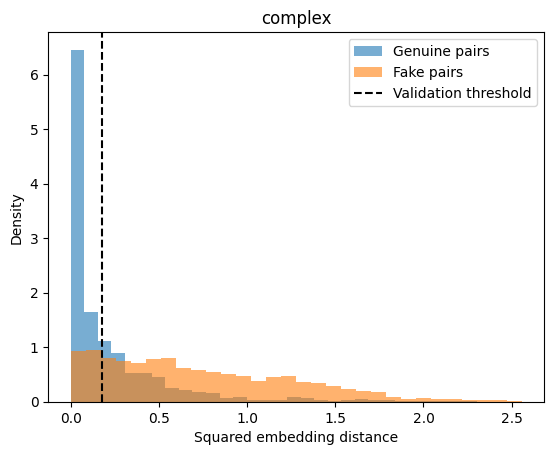

complex: Correct genuine = 1260


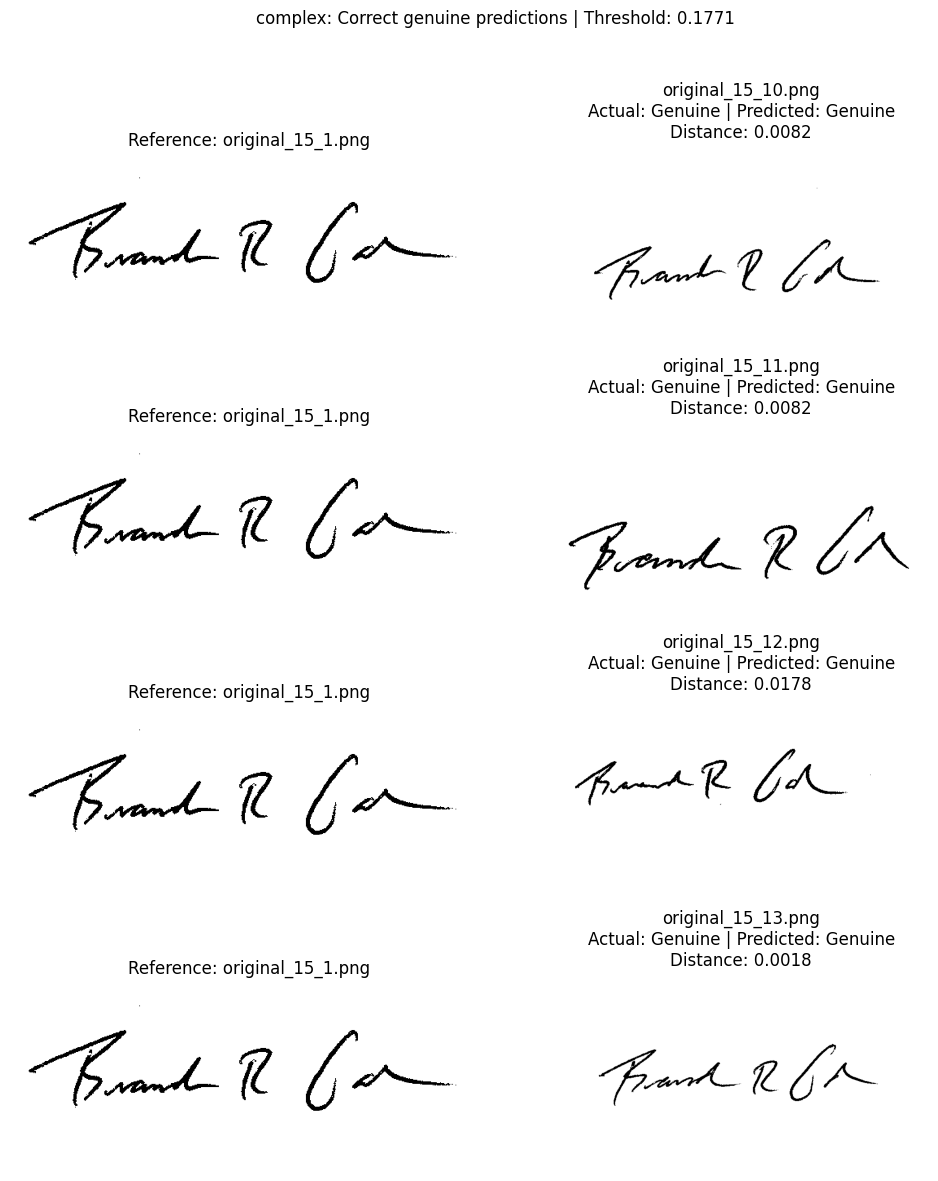

complex: Correct fake = 3368


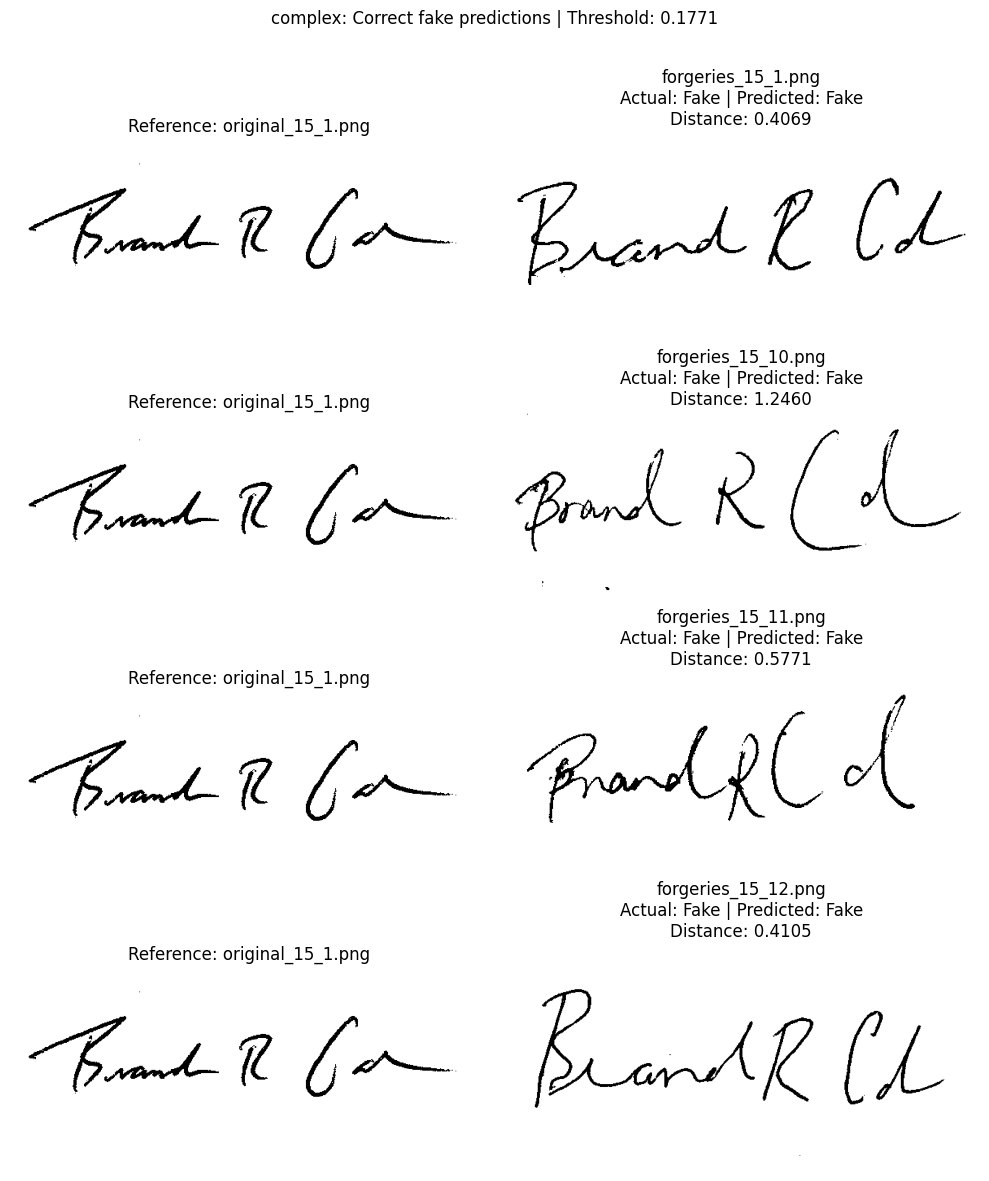

complex: Fake predicted genuine = 664


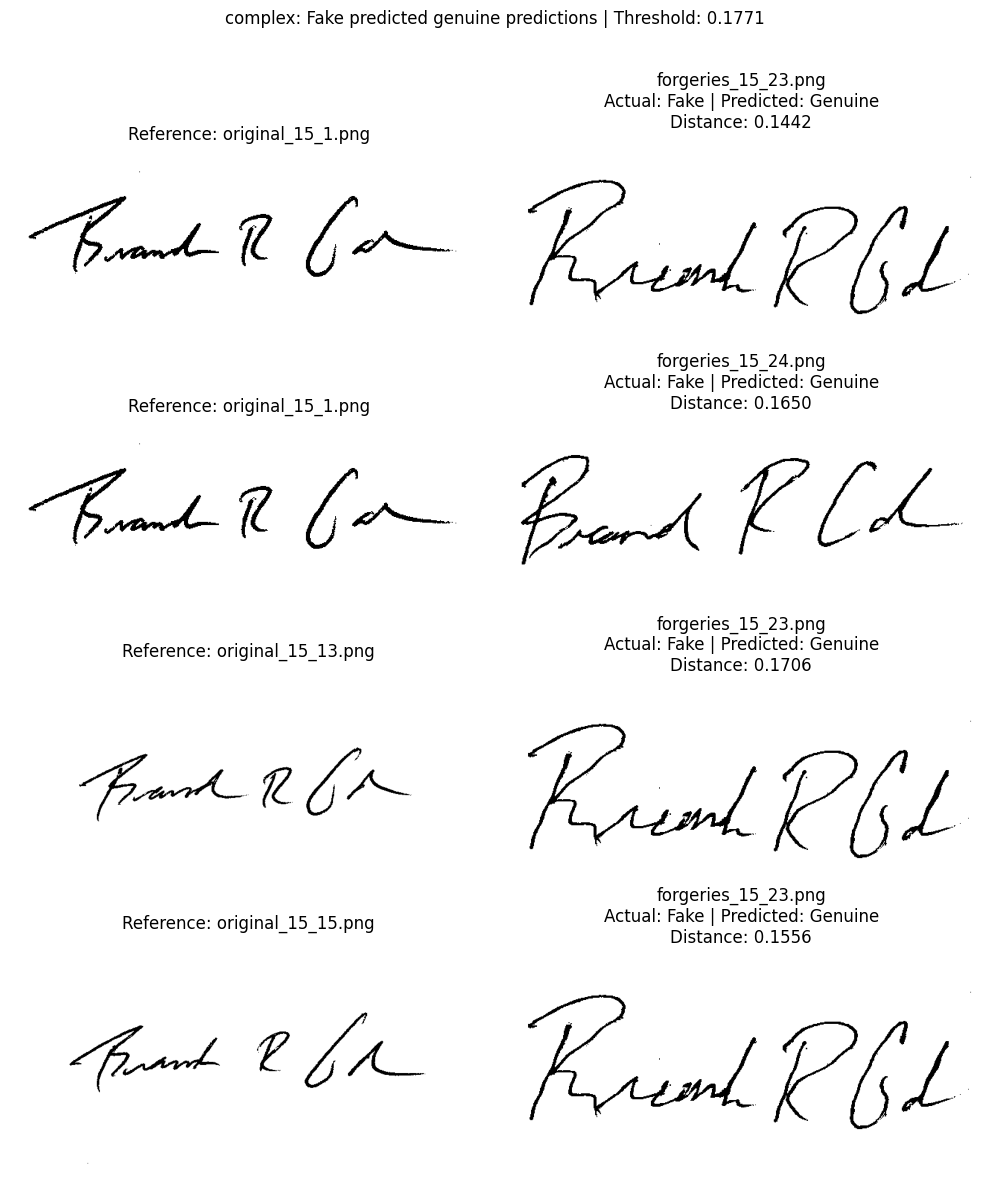

complex: Genuine predicted fake = 672


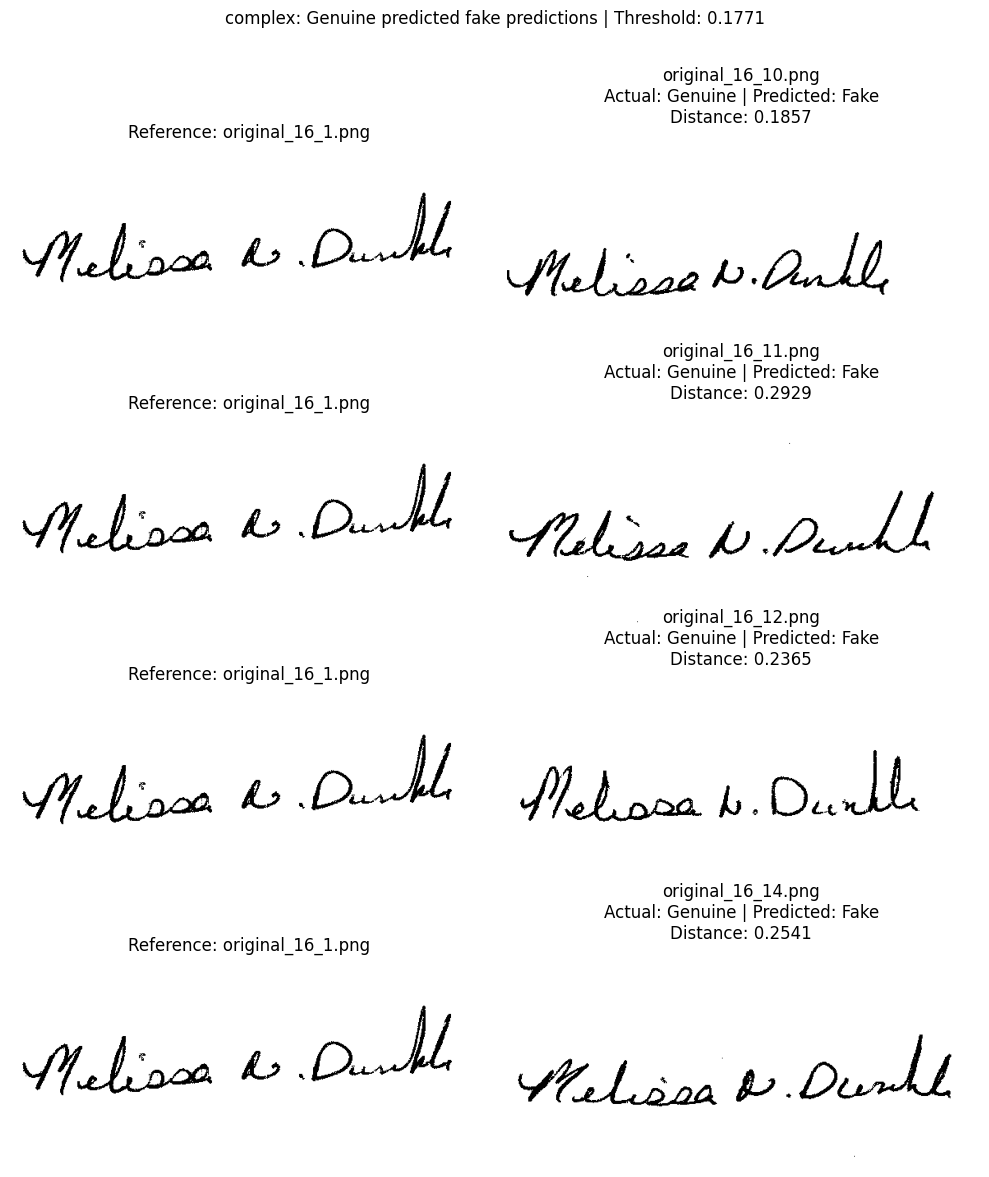

densenet121 | Accuracy: 84.44% | Precision: 0.8691 | Recall: 0.6118 | F1: 0.7181 | AUC: 0.8930
Confusion matrix: rows = actual, columns = predicted; 0 = forged, 1 = genuine
[[3854, 178], [750, 1182]]
Triplet metrics (sampled triplets): {'triplet_loss': 0.07652340829372406, 'triplet_accuracy': 0.8794642857142857, 'margin_accuracy': 0.7991071428571429}


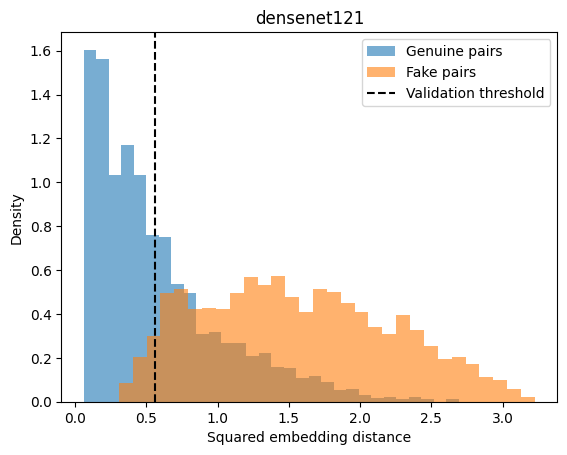

densenet121: Correct genuine = 1182


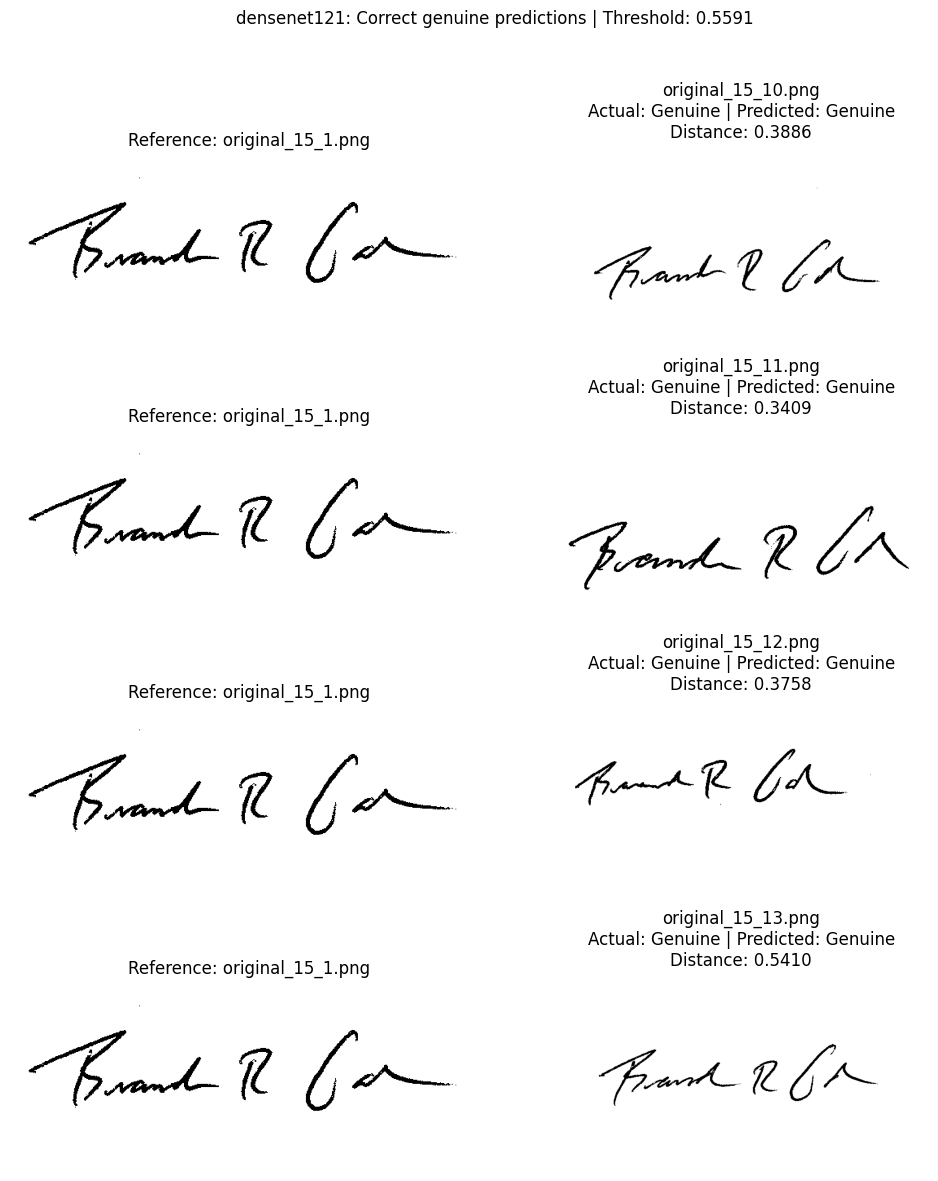

densenet121: Correct fake = 3854


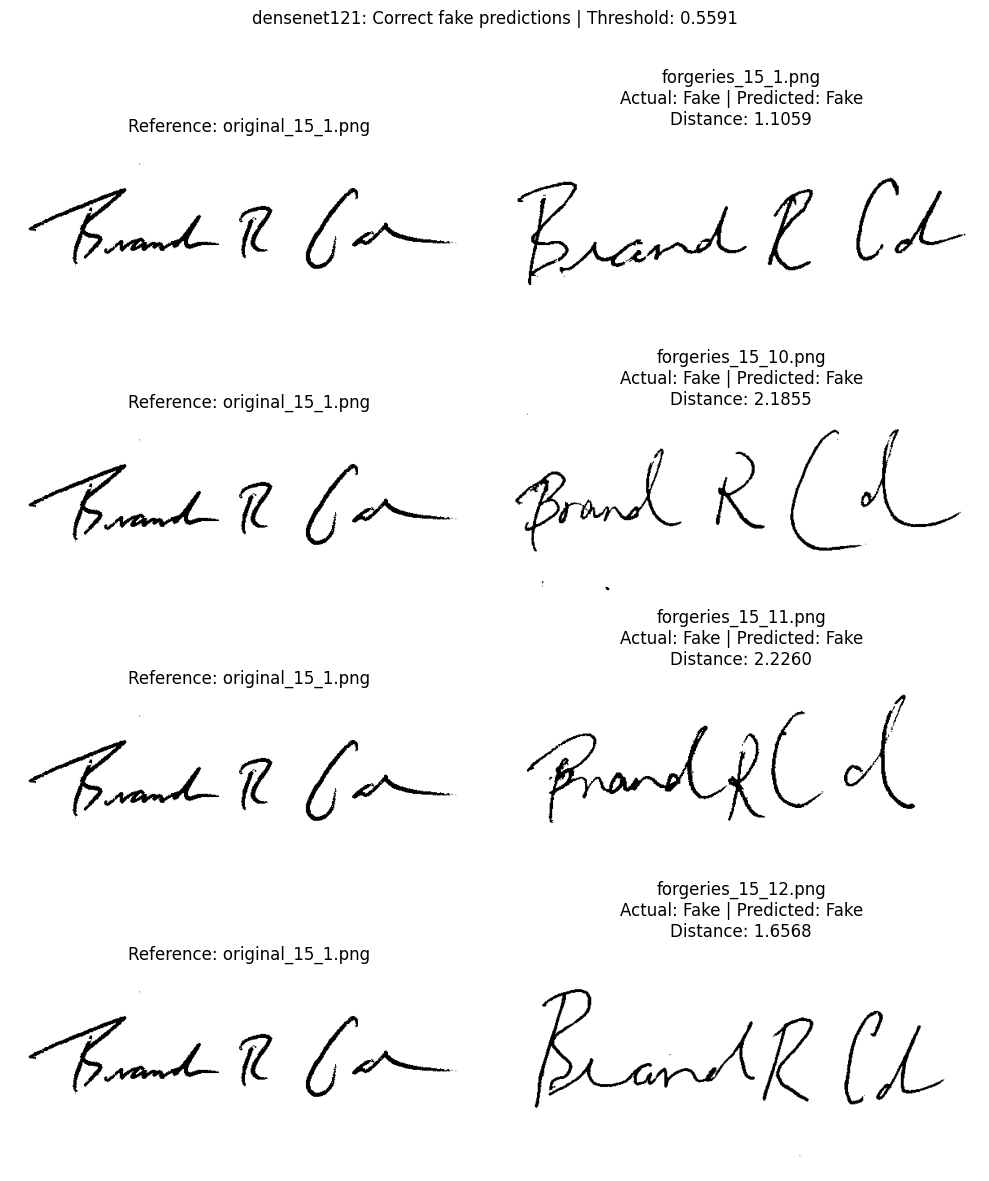

densenet121: Fake predicted genuine = 178


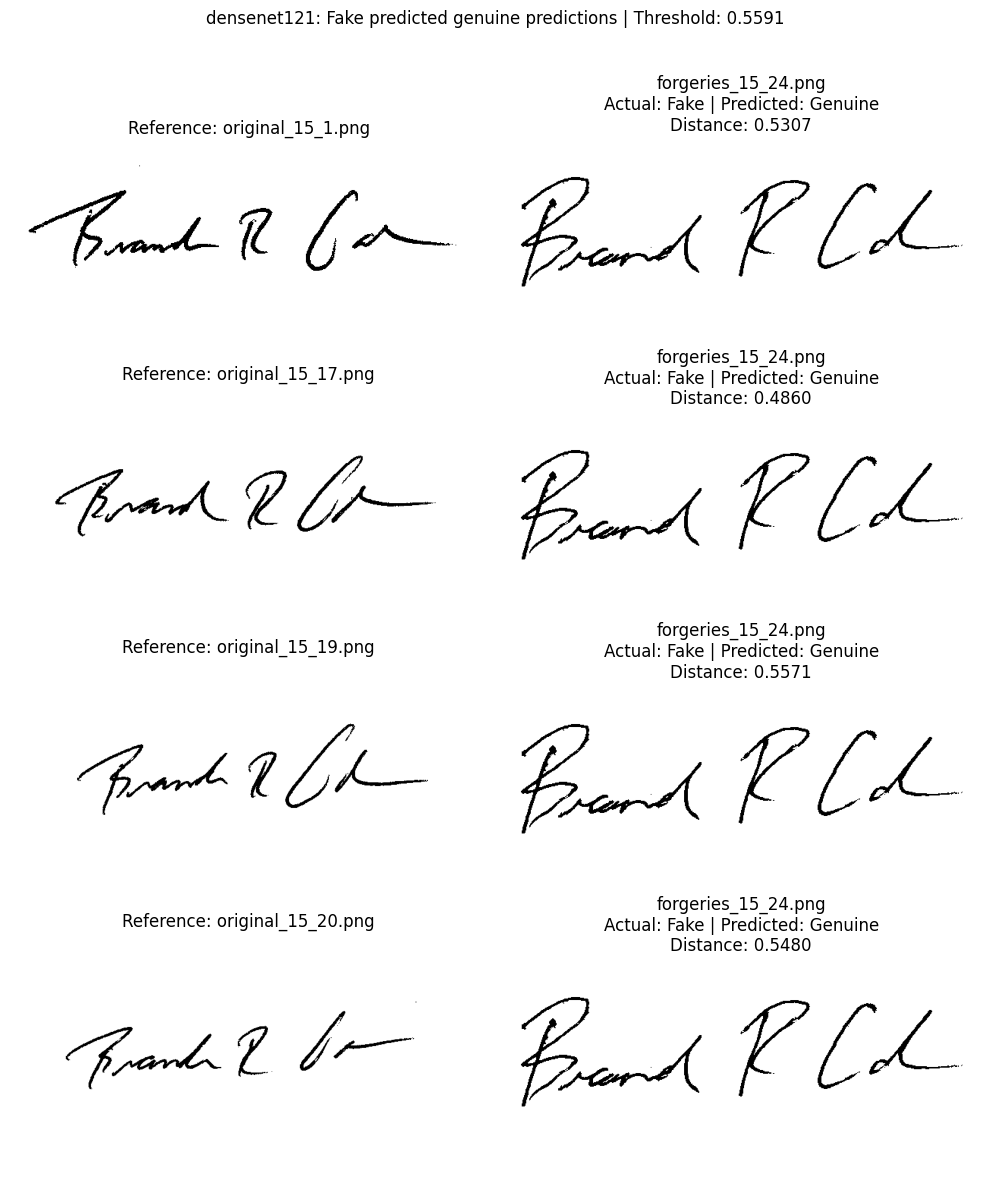

densenet121: Genuine predicted fake = 750


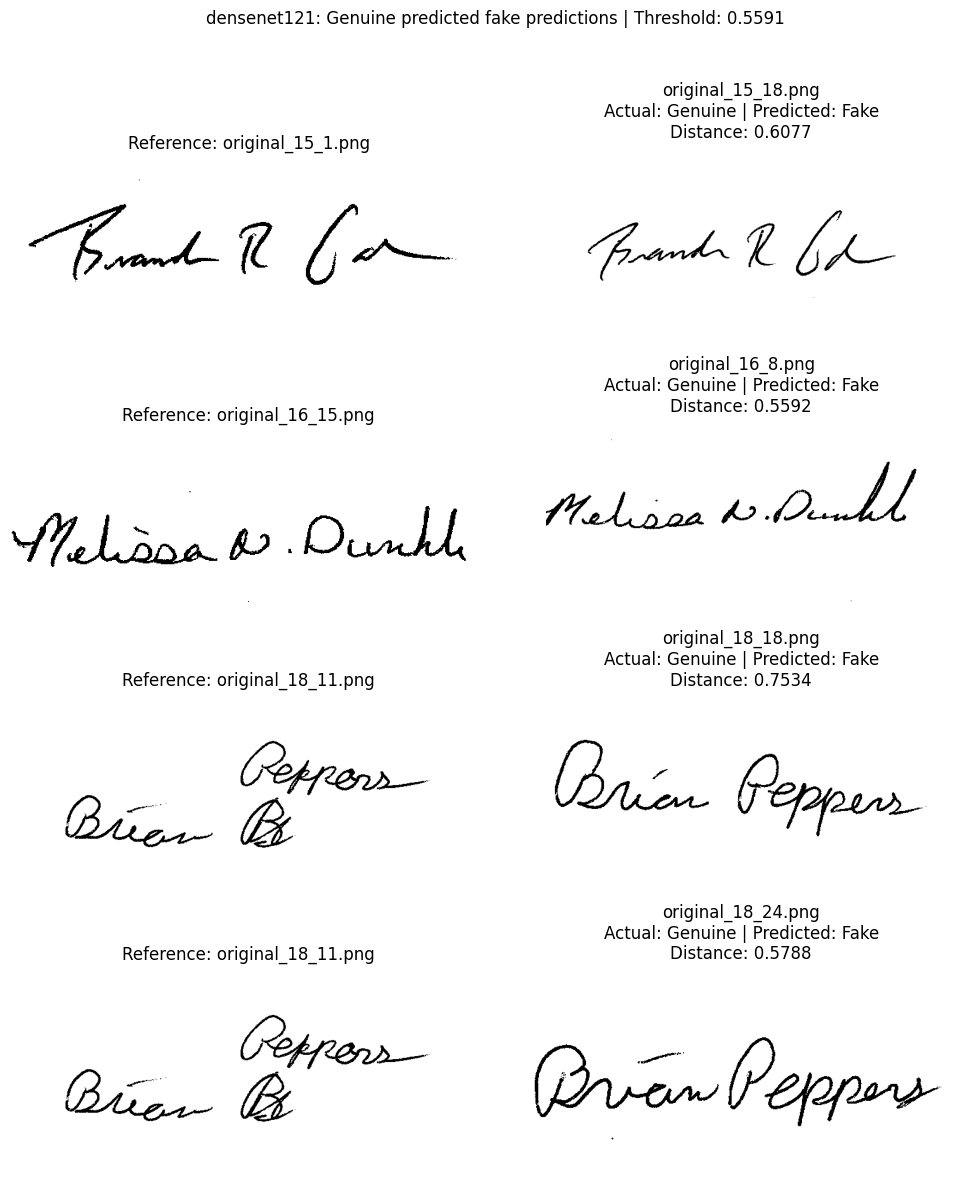

efficientnet_b0 | Accuracy: 81.57% | Precision: 0.7111 | Recall: 0.7262 | F1: 0.7186 | AUC: 0.8839
Confusion matrix: rows = actual, columns = predicted; 0 = forged, 1 = genuine
[[3462, 570], [529, 1403]]
Triplet metrics (sampled triplets): {'triplet_loss': 0.05891925096511841, 'triplet_accuracy': 0.8928571428571429, 'margin_accuracy': 0.8169642857142857}


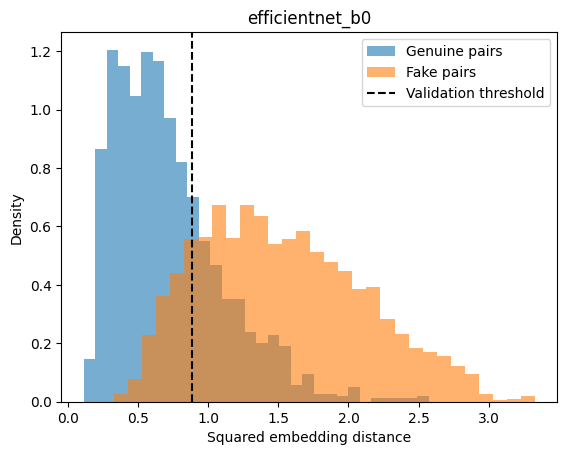

efficientnet_b0: Correct genuine = 1403


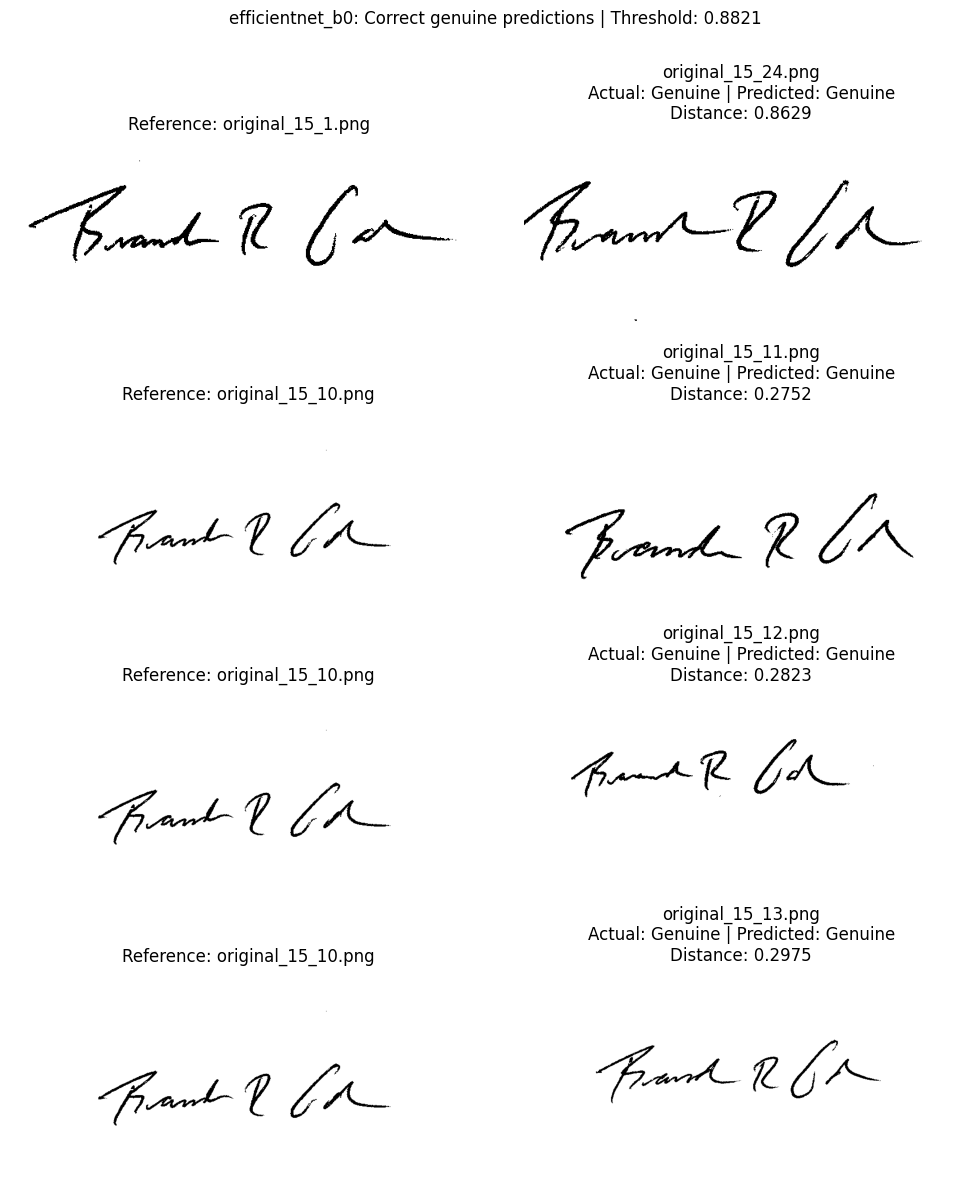

efficientnet_b0: Correct fake = 3462


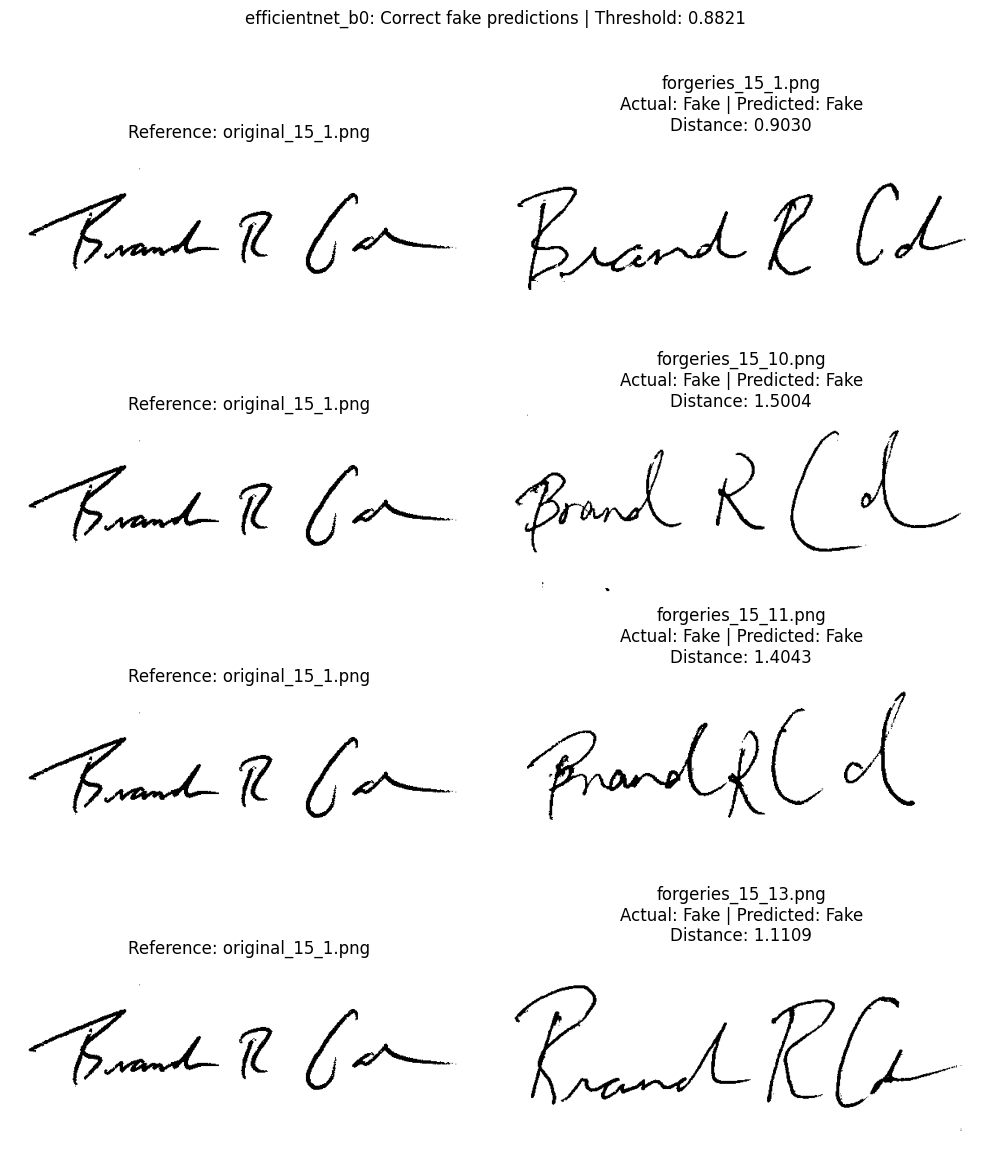

efficientnet_b0: Fake predicted genuine = 570


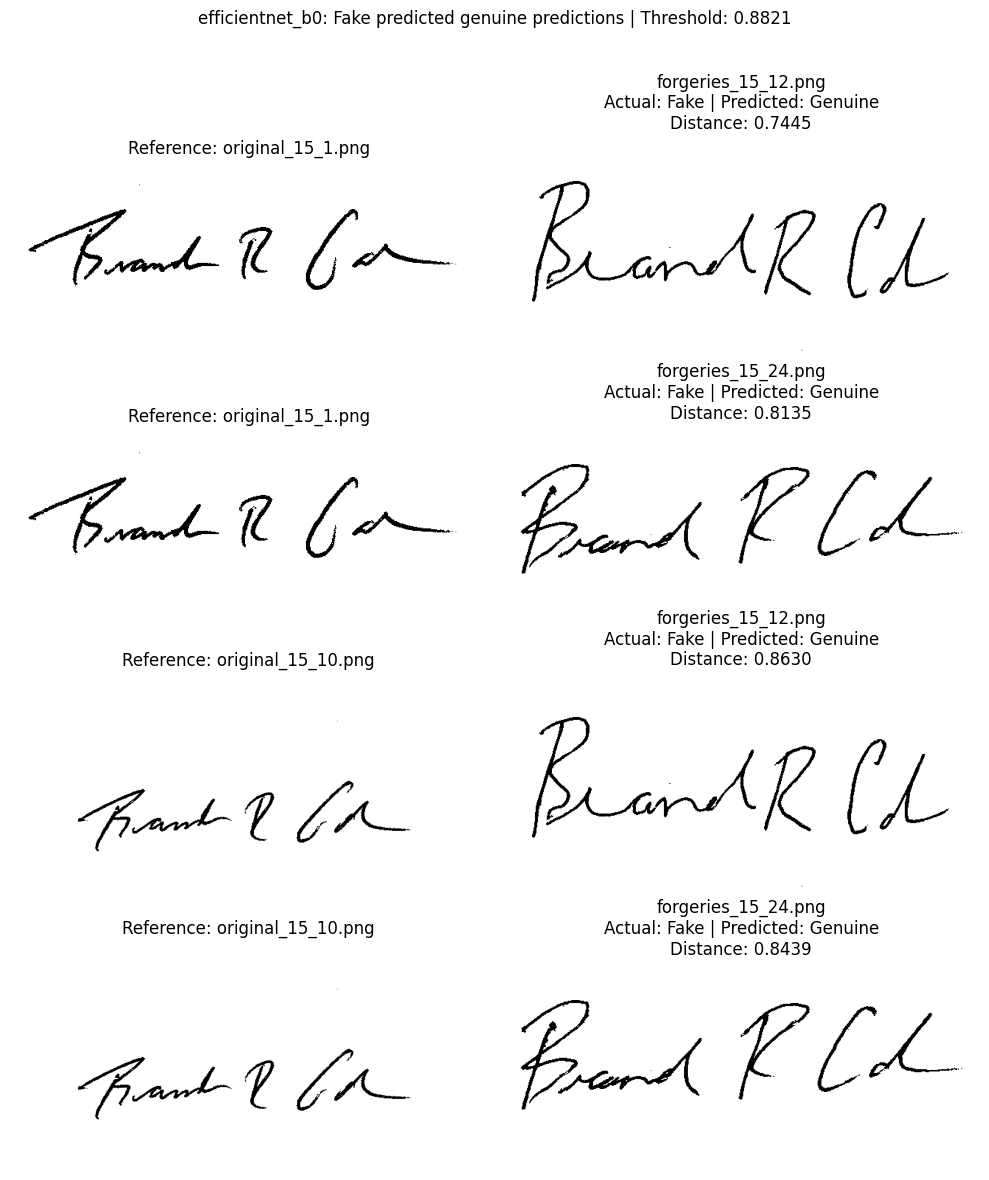

efficientnet_b0: Genuine predicted fake = 529


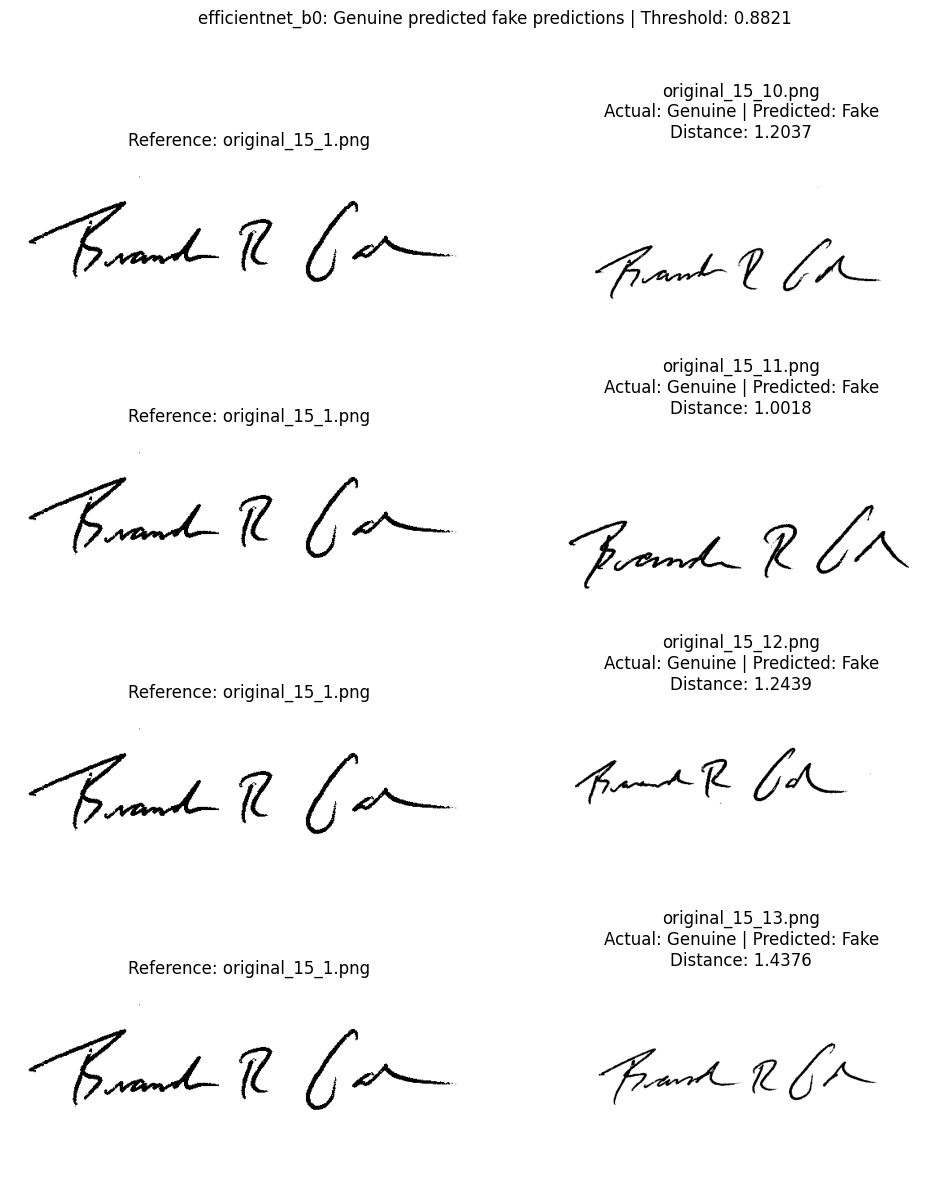

mobilenet_v3_small | Accuracy: 80.80% | Precision: 0.9019 | Recall: 0.4570 | F1: 0.6067 | AUC: 0.8825
Confusion matrix: rows = actual, columns = predicted; 0 = forged, 1 = genuine
[[3936, 96], [1049, 883]]
Triplet metrics (sampled triplets): {'triplet_loss': 0.0638110488653183, 'triplet_accuracy': 0.8883928571428571, 'margin_accuracy': 0.5}


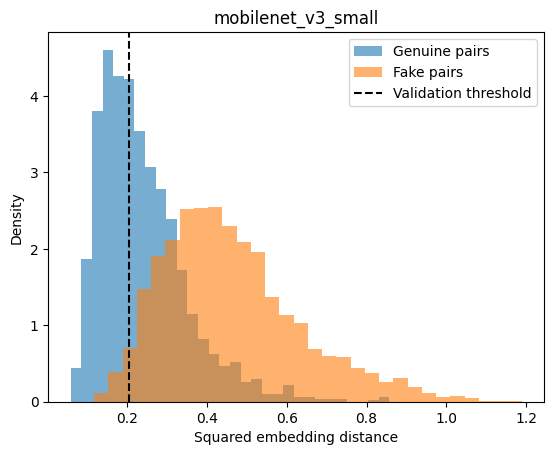

mobilenet_v3_small: Correct genuine = 883


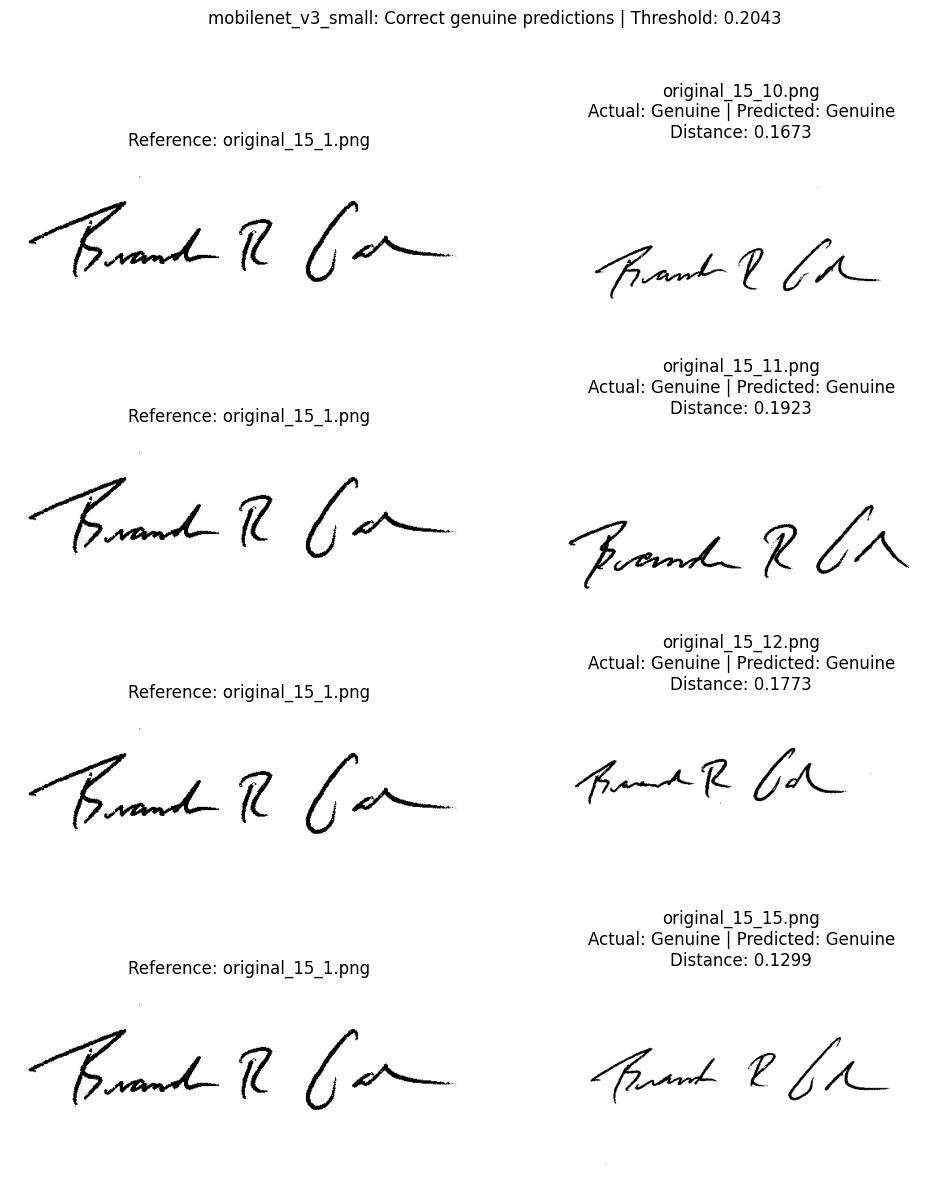

mobilenet_v3_small: Correct fake = 3936


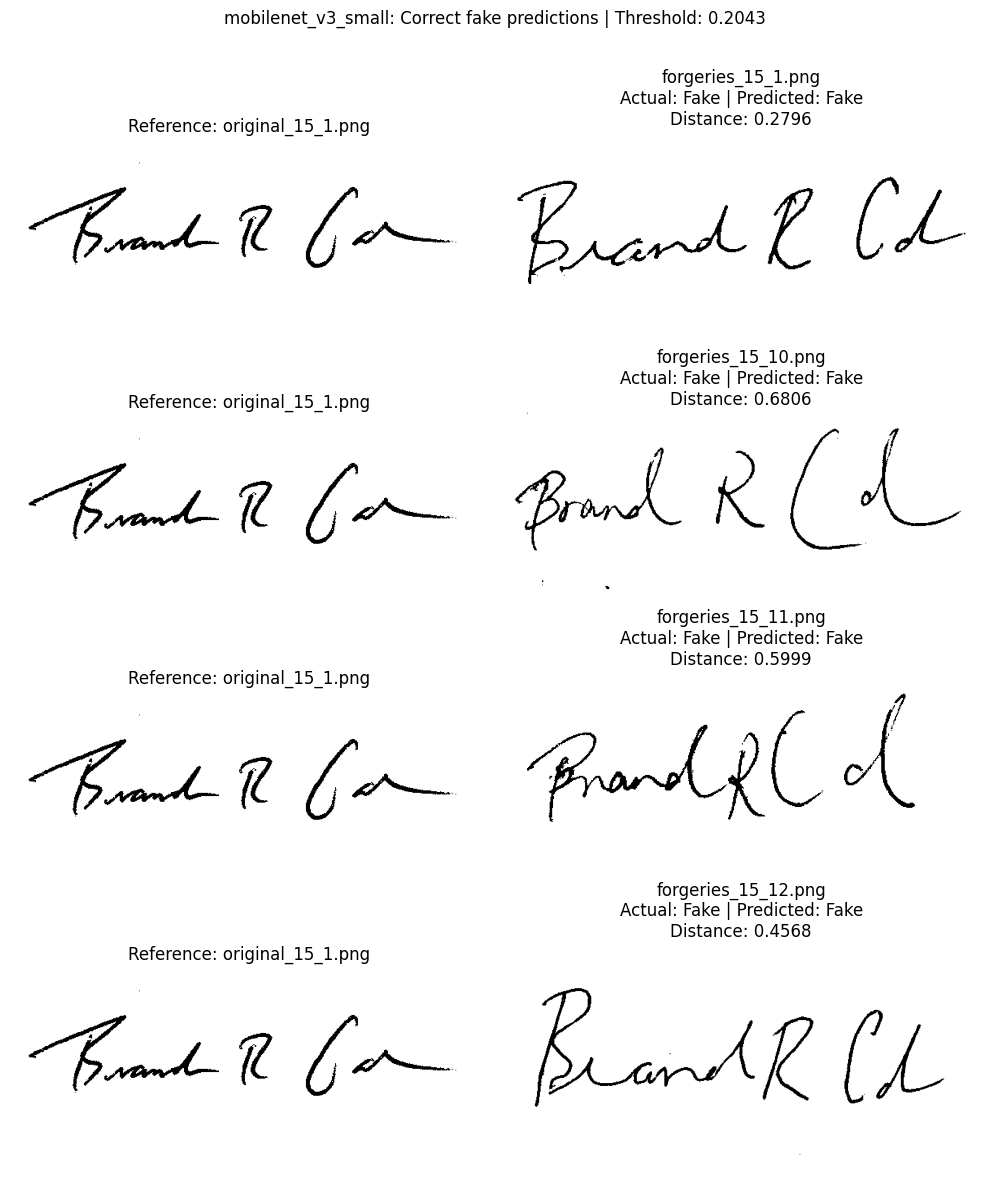

mobilenet_v3_small: Fake predicted genuine = 96


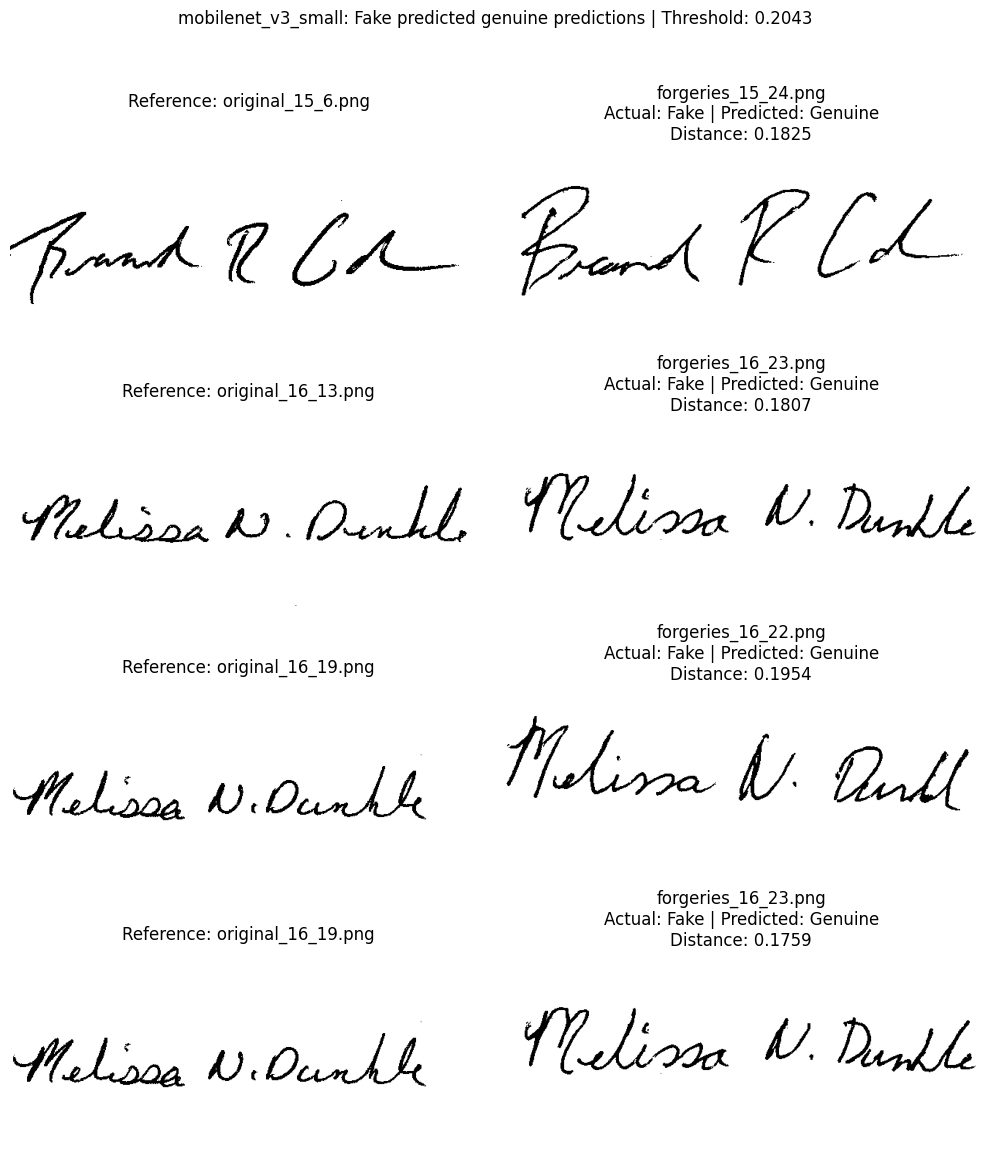

mobilenet_v3_small: Genuine predicted fake = 1049


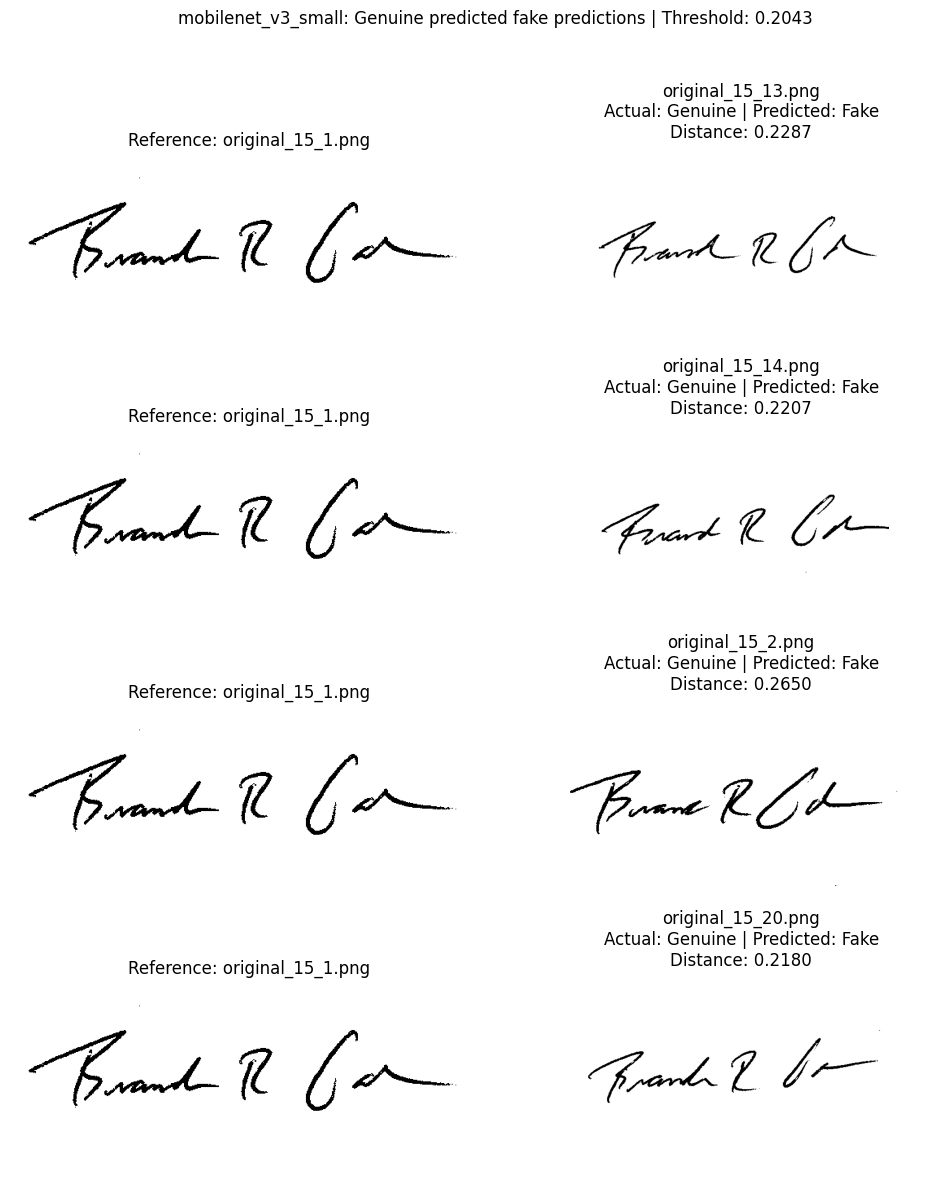

resnet18 | Accuracy: 82.33% | Precision: 0.7407 | Recall: 0.6993 | F1: 0.7194 | AUC: 0.8996
Confusion matrix: rows = actual, columns = predicted; 0 = forged, 1 = genuine
[[3559, 473], [581, 1351]]
Triplet metrics (sampled triplets): {'triplet_loss': 0.04607697203755379, 'triplet_accuracy': 0.9017857142857143, 'margin_accuracy': 0.7991071428571429}


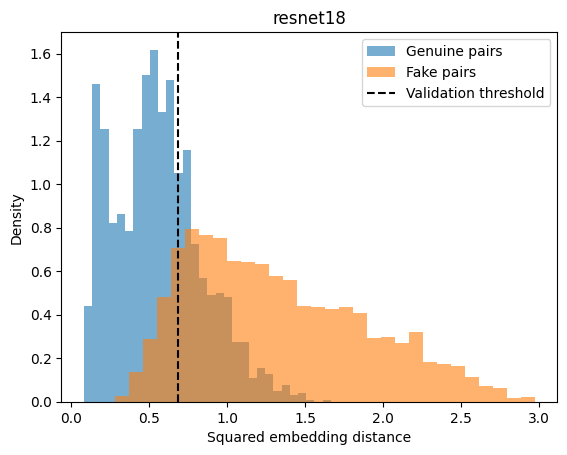

resnet18: Correct genuine = 1351


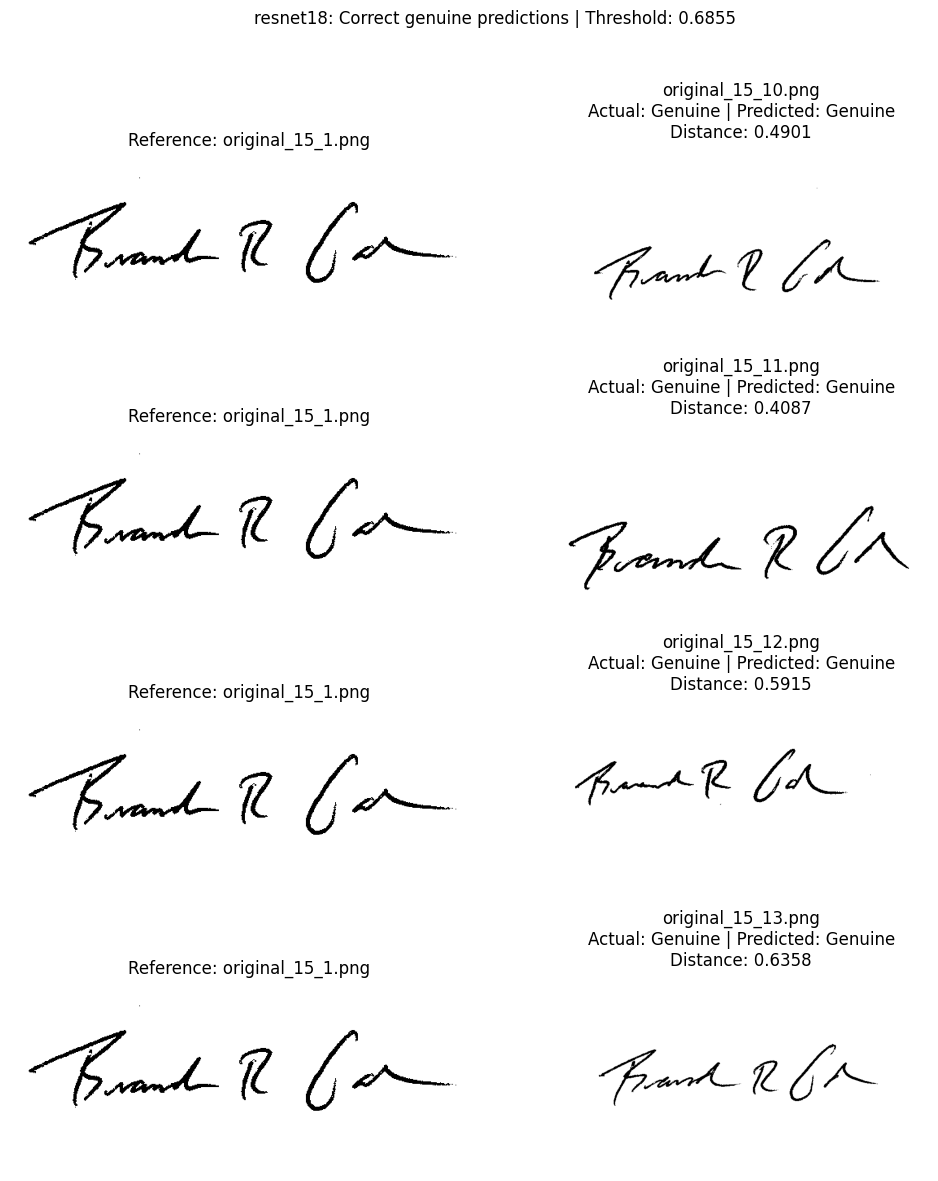

resnet18: Correct fake = 3559


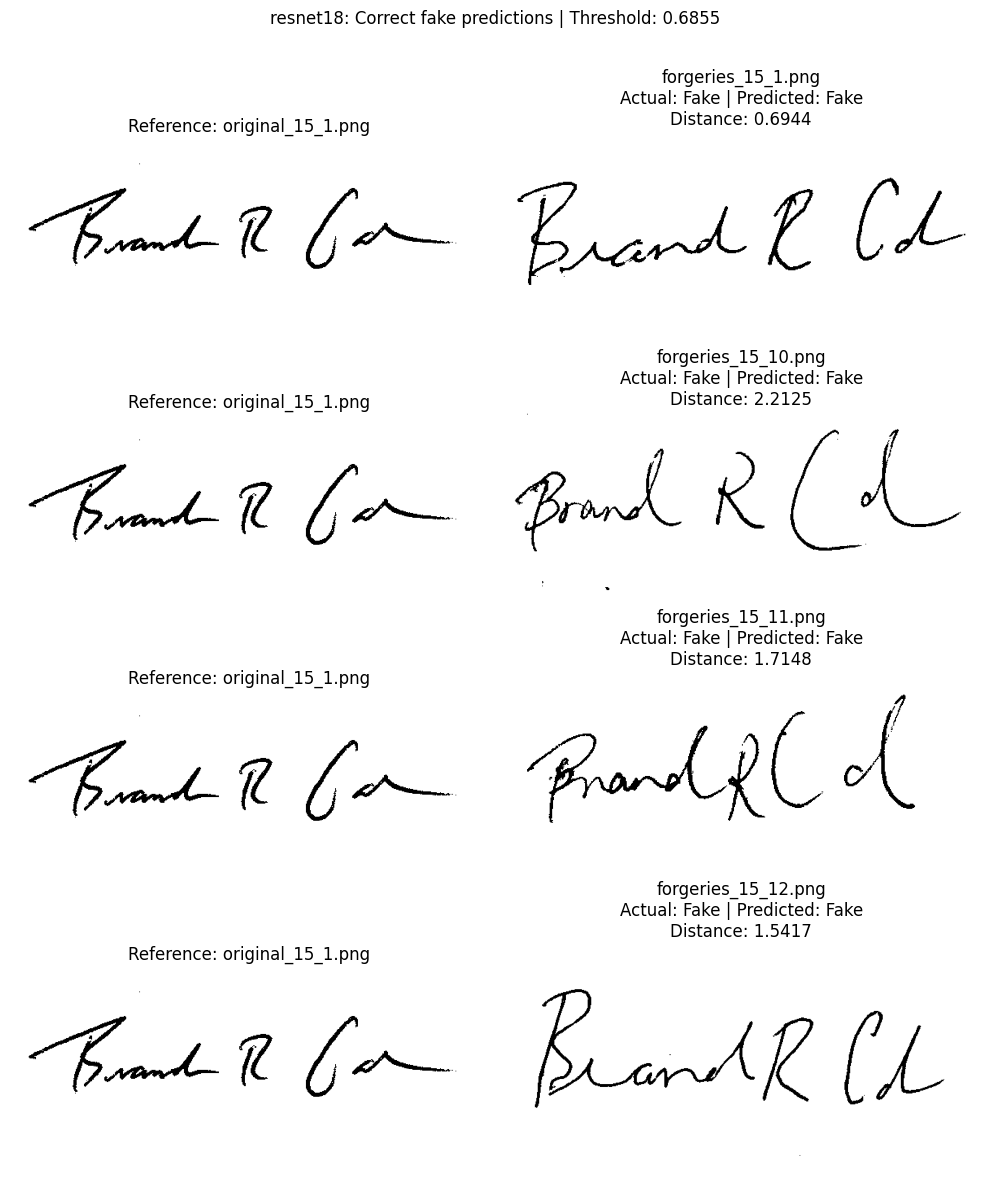

resnet18: Fake predicted genuine = 473


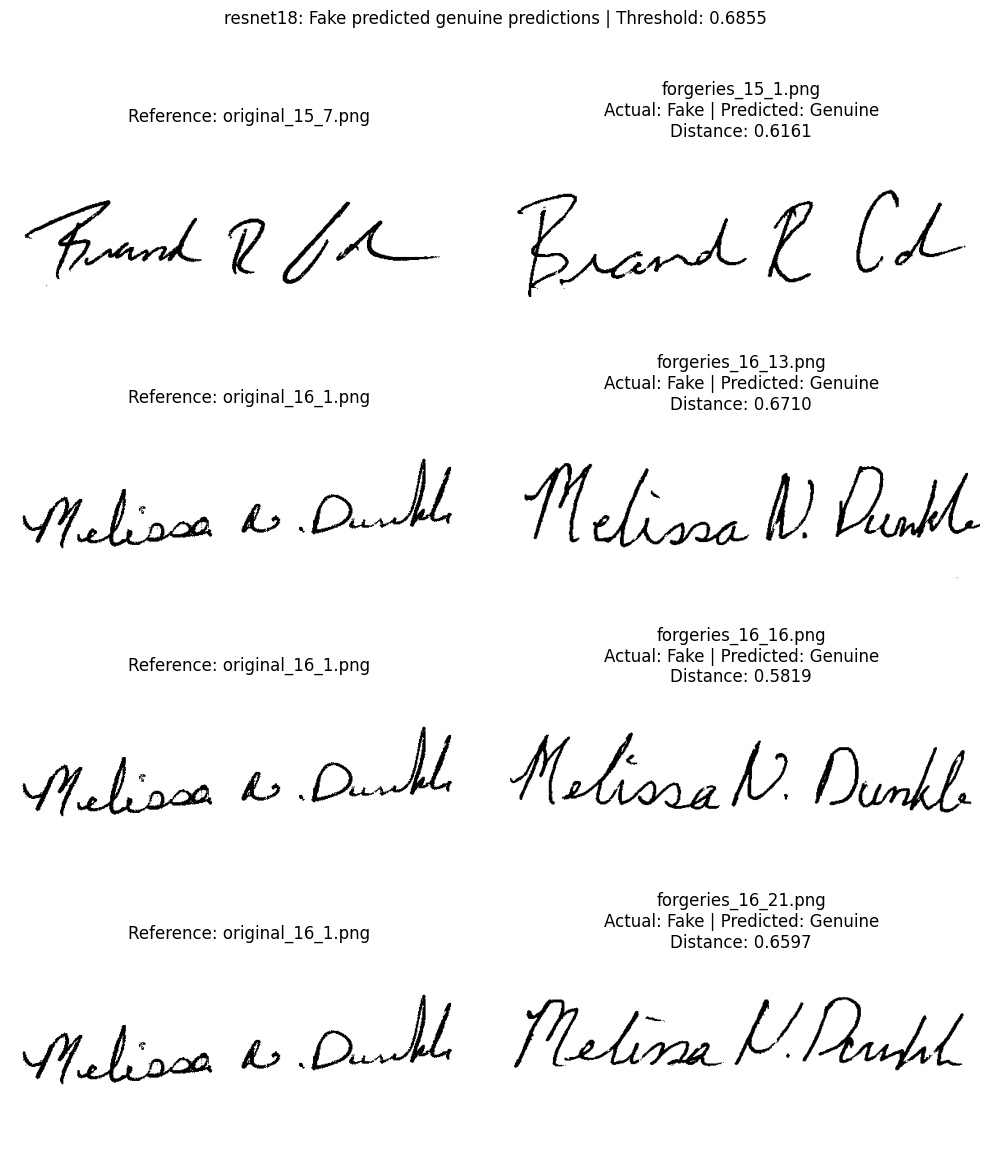

resnet18: Genuine predicted fake = 581


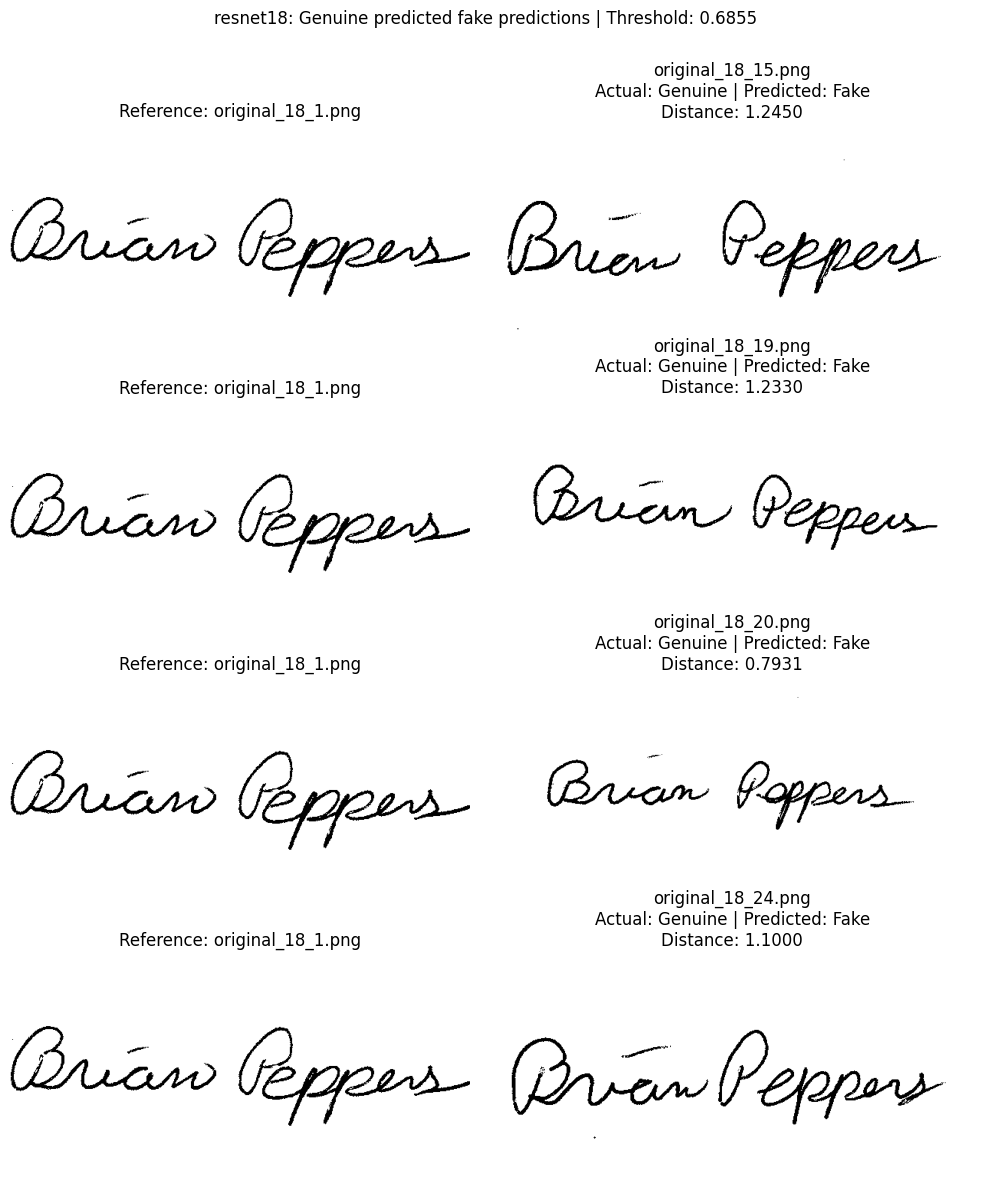

simple | Accuracy: 73.31% | Precision: 0.6384 | Recall: 0.4058 | F1: 0.4962 | AUC: 0.7485
Confusion matrix: rows = actual, columns = predicted; 0 = forged, 1 = genuine
[[3588, 444], [1148, 784]]
Triplet metrics (sampled triplets): {'triplet_loss': 0.10150308161973953, 'triplet_accuracy': 0.8035714285714286, 'margin_accuracy': 0.5848214285714286}


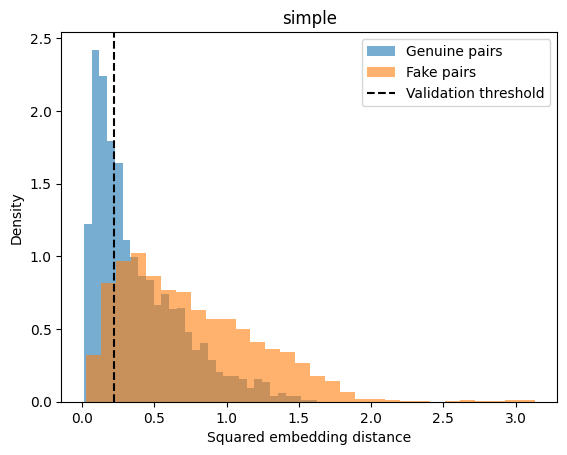

simple: Correct genuine = 784


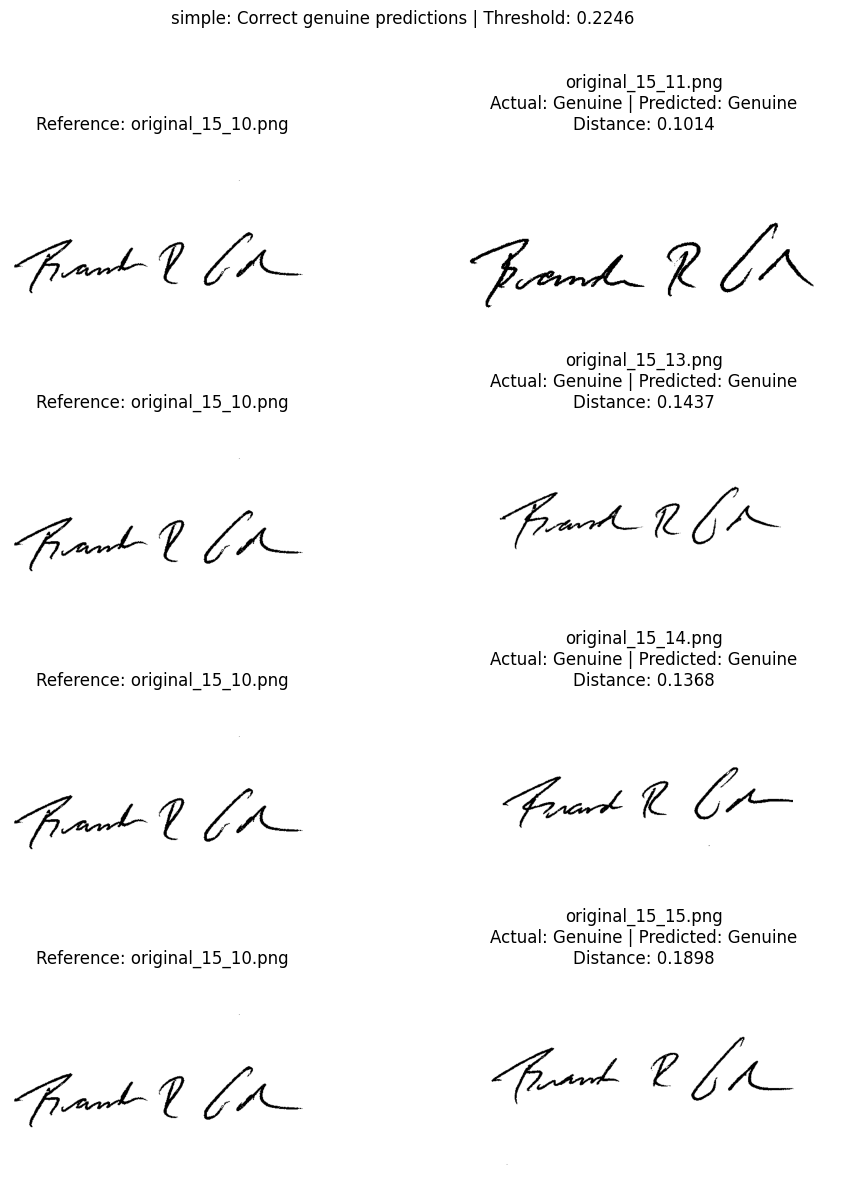

simple: Correct fake = 3588


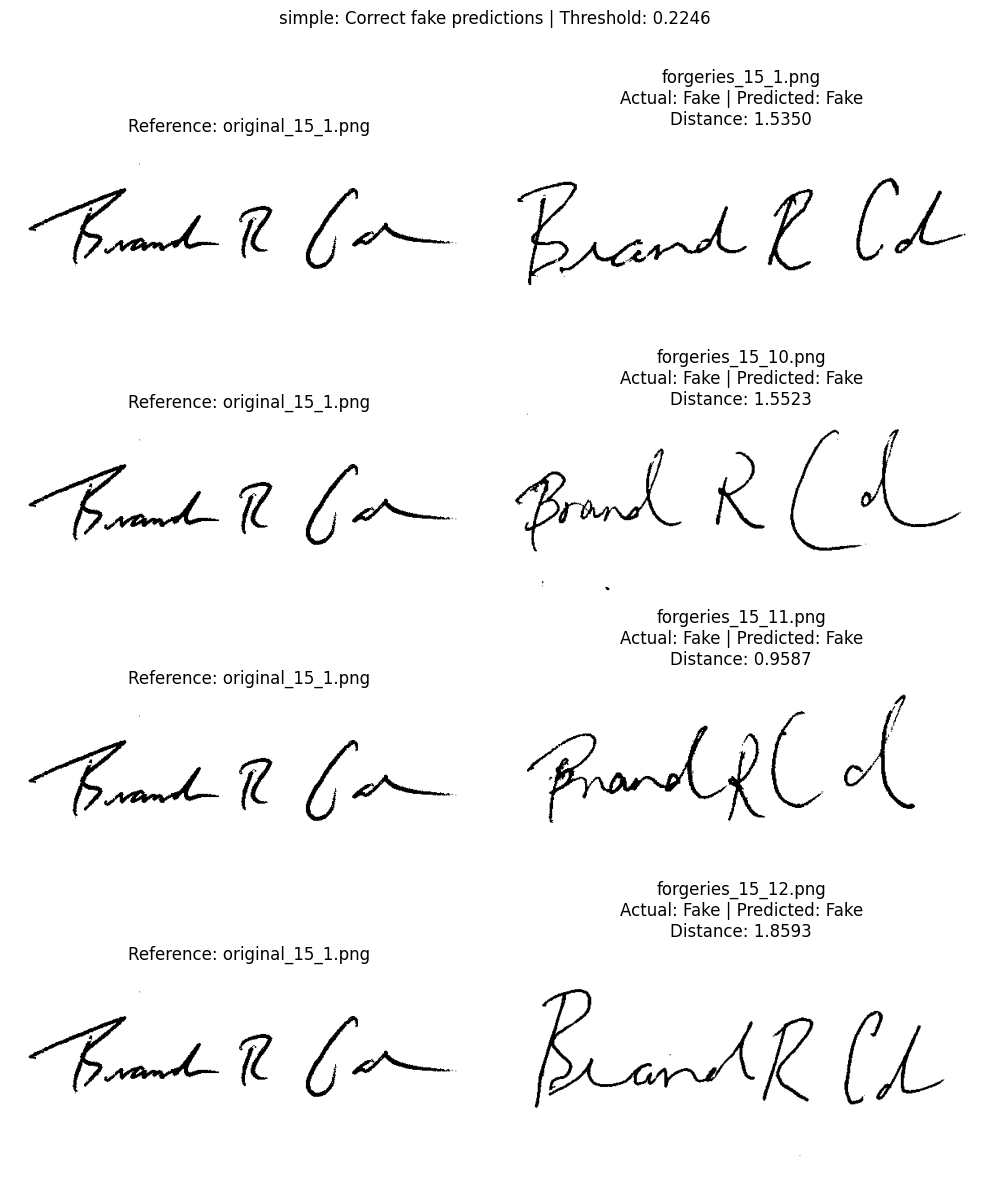

simple: Fake predicted genuine = 444


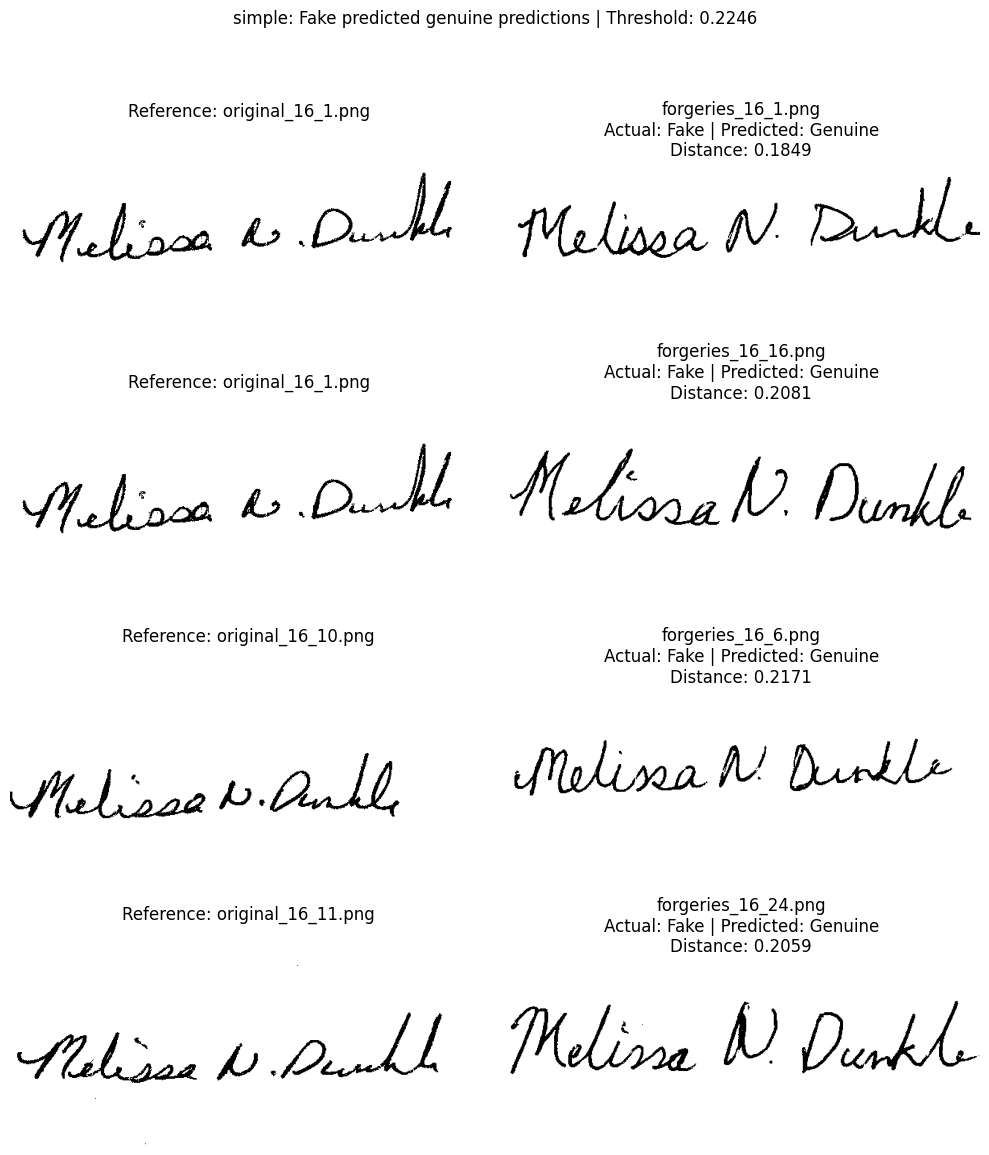

simple: Genuine predicted fake = 1148


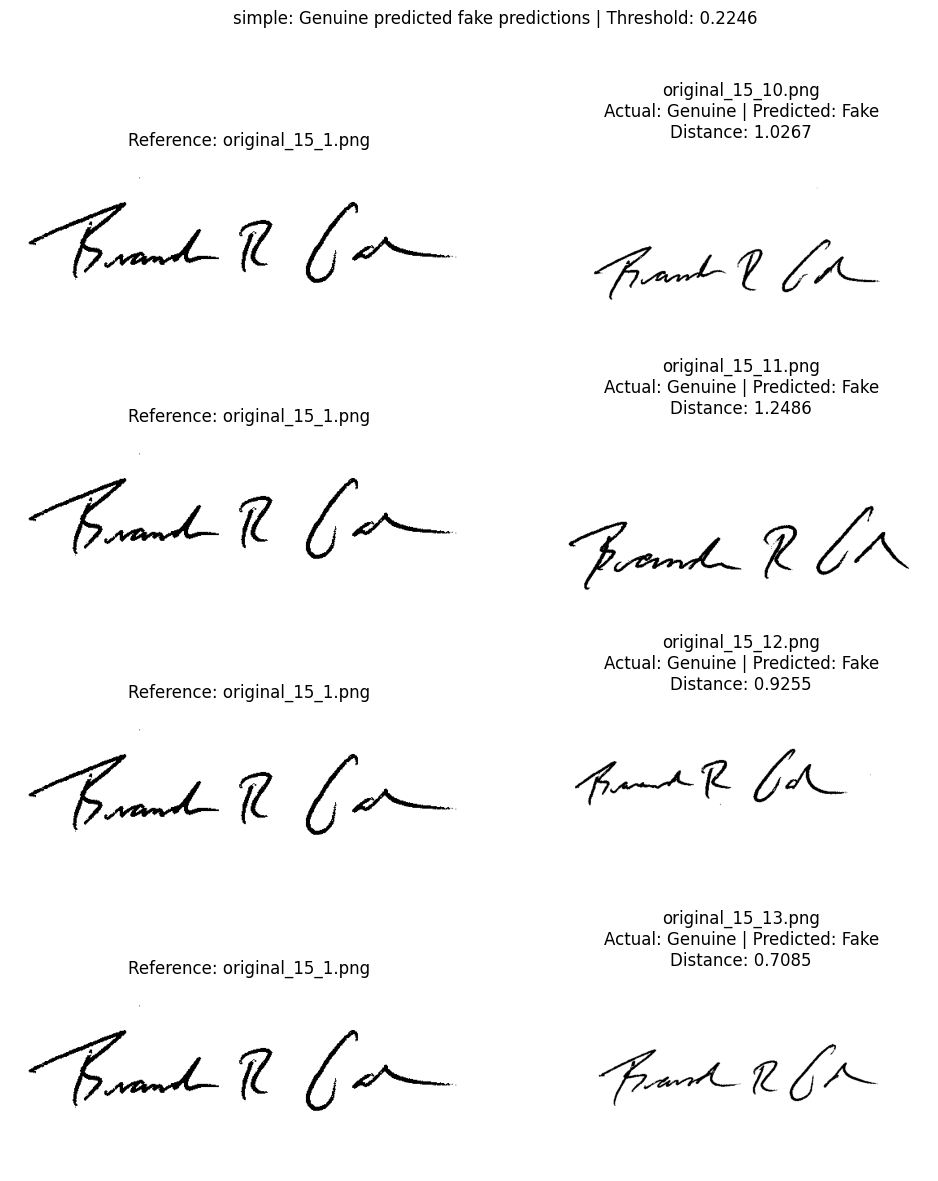

In [5]:
results = []
for path in paths:
    checkpoint = torch.load(path, map_location="cpu", weights_only=True)
    name = checkpoint["name"]
    config = checkpoint["config"]
    if config.get("preprocessing") != "otsu":
        raise ValueError(f"{name}: train again with Otsu preprocessing before testing.")
    if config["train_w"] != train_w or config["val_w"] != val_w or config["test_w"] != test_w:
        raise ValueError(f"{name}: saved writer split does not match.")
    if name == "simple":
        model = build_simple(config["image_size"], config["embedding_dim"])
    elif name == "complex":
        model = build_complex(config["embedding_dim"])
    else:
        model = build_pretrained(name, config["embedding_dim"])
    model.load_state_dict(checkpoint["state_dict"])
    model = model.to(DEVICE).eval()
    test_config = dict(config)
    test_config["batch_size"] = BATCH_SIZE

    val_distance, val_labels = pair_distances(model, name, val_triplets, test_config, DEVICE)
    threshold = select_threshold(val_distance, val_labels)
    val_metrics = calculate_metrics(val_distance, val_labels, threshold)
    triplet_distance, triplet_labels = pair_distances(model, name, test_triplets, test_config, DEVICE)
    triplet_metrics = calculate_triplet_metrics(triplet_distance, triplet_labels, config["margin"])
    distance, labels = test_pair_distances(model, name, test_pairs, test_config, DEVICE)
    metrics = calculate_metrics(distance, labels, threshold)
    result = {
        "model": name, "preprocessing": "otsu", "threshold": threshold,
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "val_auc": val_metrics["auc"],
    }
    result.update({f"test_{key}": value for key, value in metrics.items()})
    result.update({f"test_{key}": value for key, value in triplet_metrics.items()})
    results.append(result)
    threshold_path = MODEL_DIR / f"{name}_threshold.json"
    threshold_path.write_text(json.dumps({"threshold": threshold, "image_size": config["image_size"], "preprocessing": "otsu"}, indent=2))
    print(f"{name} | Accuracy: {metrics['accuracy']:.2%} | Precision: {metrics['precision']:.4f} | Recall: {metrics['recall']:.4f} | F1: {metrics['f1']:.4f} | AUC: {metrics['auc']:.4f}")
    print("Confusion matrix: rows = actual, columns = predicted; 0 = forged, 1 = genuine")
    print([[metrics["tn"], metrics["fp"]], [metrics["fn"], metrics["tp"]]])
    print("Triplet metrics (sampled triplets):", triplet_metrics)
    plot_distances(distance, labels, threshold, name)
    show_pairs(test_pairs, distance, labels, threshold, name, N_SHOW)
    del model, checkpoint
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Model                   Validation accuracy   Test accuracy     Test AUC
complex                              75.39%          77.60%       0.8321
densenet121                          76.37%          84.44%       0.8930
efficientnet_b0                      76.37%          81.57%       0.8839
mobilenet_v3_small                   74.61%          80.80%       0.8825
resnet18                             74.61%          82.33%       0.8996
simple                               65.43%          73.31%       0.7485
Best model by validation: efficientnet_b0


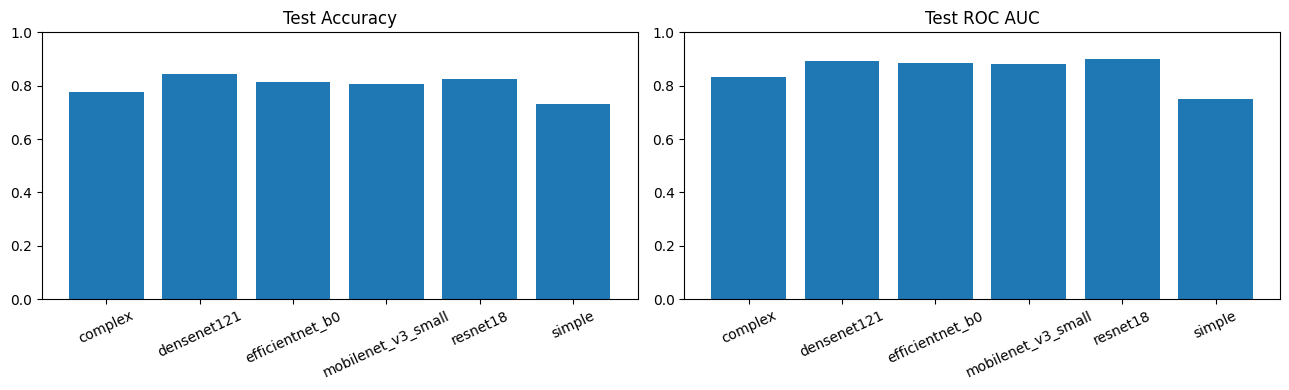

In [6]:
with (MODEL_DIR / "test_results.csv").open("w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=list(results[0]))
    writer.writeheader()
    writer.writerows(results)

print(f"{'Model':<22} {'Validation accuracy':>20} {'Test accuracy':>15} {'Test AUC':>12}")
for row in results:
    print(f"{row['model']:<22} {row['val_balanced_accuracy']:>20.2%} {row['test_accuracy']:>15.2%} {row['test_auc']:>12.4f}")

best = max(results, key=lambda row: (row["val_balanced_accuracy"], row["val_auc"]))
print("Best model by validation:", best["model"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for axis, metric, title in zip(axes, ["test_accuracy", "test_auc"], ["Test Accuracy", "Test ROC AUC"]):
    axis.bar([row["model"] for row in results], [row[metric] for row in results])
    axis.set_ylim(0, 1)
    axis.set_title(title)
    axis.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()